## ASE sandbox
building structures, visualization, EMT relaxation

#### 1. imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from ase import Atoms
from ase.build import bulk, molecule, surface, add_adsorbate
from ase.visualize.plot import plot_atoms
from ase.calculators.emt import EMT
from ase.optimize import BFGS
from ase.io import write
from ase.eos import EquationOfState

#### 2. building structures

**terms**
* bulk structure: infinite in 3 dims (x, y z) w/ periodic boundary conds
* slab structure: infinite in 2 dims (x, y) w/ surface z

In [7]:
# Atoms obj is list of atoms w/ positions, unit cell type, unit cell length (PBC)

# fcc copper bulk crystal
cu = bulk('Cu', 'fcc', a=3.6)  # a in Angstroms
print(cu)
print('Positions:', cu.positions)
print('Cell:', cu.cell)
print('PBC:', cu.pbc)  # gives whether system is periodic in each direction


Atoms(symbols='Cu', pbc=True, cell=[[0.0, 1.8, 1.8], [1.8, 0.0, 1.8], [1.8, 1.8, 0.0]])
Positions: [[0. 0. 0.]]
Cell: Cell([[0.0, 1.8, 1.8], [1.8, 0.0, 1.8], [1.8, 1.8, 0.0]])
PBC: [ True  True  True]


In [8]:
# water molecule (no periodic boundaries)
h2o = molecule('H2O')
print(h2o)
print('Symbols:', h2o.get_chemical_symbols())
print('Positions:', h2o.positions)

Atoms(symbols='OH2', pbc=False)
Symbols: ['O', 'H', 'H']
Positions: [[ 0.        0.        0.119262]
 [ 0.        0.763239 -0.477047]
 [ 0.       -0.763239 -0.477047]]


#### 3. visualization

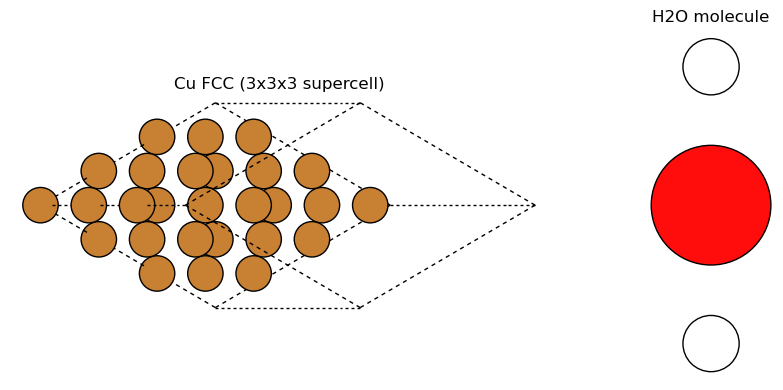

In [10]:
# inline 2D rendering w/ plot_atoms

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  
# 1 row, 2 cols of subplots, total fig. is 10 x 4 inches
# axes[0] is left fig., axes[1] is right

# cu supercell (cell repeated 3x in each dir.)
cu_super = cu.repeat([3, 3, 3])
plot_atoms(cu_super, axes[0], radii=0.5, rotation=('45x,45y,0z'))  # radii is drawn atom size as fraction of covalent radius
axes[0].set_title('Cu FCC (3x3x3 supercell)')
axes[0].axis('off')

# h20
plot_atoms(h2o, axes[1], radii=0.5)
axes[1].set_title('H2O molecule')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# 3d viewer, open in VESTA

from ase.io import write

In [ ]:
write('cu.xyz', cu_super)
write('cu.cif', cu_super)  # export to CIF format